##### Extraction by transformers

In [24]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import warnings

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [25]:

# Define image preprocessing
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])



In [26]:
try:
    # Load DINOv2 model
    dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitg14')
    dinov2.eval()
    dinov2.to(device)
    print(f"DINOv2 model loaded successfully on {device}")
except Exception as e:
    print(f"Error loading DINOv2 model: {str(e)}")
    raise



Using cache found in C:\Users\gueid/.cache\torch\hub\facebookresearch_dinov2_main


DINOv2 model loaded successfully on cpu


In [27]:
def extract_dino_descriptor(image):
    """
    Extract DINOv2 descriptor from an image
    
    Args:
        image: PIL Image or torch.Tensor
    
    Returns:
        numpy array: Global descriptor
    """
    try:
        # Handle different input types
        if isinstance(image, Image.Image):
            image_tensor = transform(image)
        elif isinstance(image, torch.Tensor):
            image_tensor = image
        else:
            raise ValueError("Input must be PIL Image or torch.Tensor")
            
        # Add batch dimension if needed
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)
            
        # Move to device
        image_tensor = image_tensor.to(device)
            
        with torch.no_grad():
            # DINOv2 returns the features directly
            features = dinov2(image_tensor)
            
            # Debug: print shape
            # print(f"Raw output shape: {features.shape}")
            
            # Extract the features
            if isinstance(features, torch.Tensor):
                global_descriptor = features
            else:
                # If features is a dictionary or has multiple outputs
                global_descriptor = features
                
            # Make sure we return a 1D array for easier processing
            flattened_descriptor = global_descriptor.cpu().numpy().flatten()
                    
        return flattened_descriptor
    
    except Exception as e:
        print(f"Error extracting descriptor: {str(e)}")
        return None

In [28]:
# Example usage
def test_extraction():
    try:
        # Create a dummy image
        dummy_input = torch.randn(1, 3, 224, 224)
        print(f"Input shape: {dummy_input.shape}")
        
        # Extract features
        descriptor = extract_dino_descriptor(dummy_input)
        
        if descriptor is not None:
            print(f"Descriptor shape: {descriptor.shape}")
            print(f"Descriptor type: {type(descriptor)}")
            return True
        else:
            print("Failed to extract descriptor")
            return False
    except Exception as e:
        print(f"Test failed: {str(e)}")
        return False



In [29]:
# Run the test
print("\nRunning test extraction...")
success = test_extraction()
print(f"Test {'succeeded' if success else 'failed'}")




Running test extraction...
Input shape: torch.Size([1, 3, 224, 224])
Descriptor shape: (1536,)
Descriptor type: <class 'numpy.ndarray'>
Test succeeded


In [30]:
# Example with a real image
def extract_from_image_file(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        print(f"Loaded image from {image_path}")
        descriptor = extract_dino_descriptor(img)
        if descriptor is not None:
            print(f"Image descriptor shape: {descriptor.shape}")
        return descriptor
    except Exception as e:
        print(f"Error processing image file: {str(e)}")
        return None



In [31]:
# Uncomment to test with a real image
image_path = "data/train/amy_gardens/peach_0000.png"
extract_from_image_file(image_path)
#test_extraction()

Loaded image from data/train/amy_gardens/peach_0000.png
Image descriptor shape: (1536,)


array([0.7294797, 0.7887479, 1.4382567, ..., 2.582613 , 1.5740671,
       0.5550222], dtype=float32)

In [32]:
amy_gardens_images_dir = 'data/train/amy_gardens'


In [33]:
import os
from tqdm import tqdm


def batch_extract_descriptors(folder_path):
    """
    Extract descriptors for all images in a folder
    
    Args:
        folder_path: Path to folder containing images
        
    Returns:
        dict: Dictionary mapping image paths to their descriptors
    """
    image_descriptors = {}
    valid_extensions = ['.jpg', '.jpeg', '.png']
    
    # Get all image files
    image_files = [f for f in os.listdir(folder_path) if os.path.splitext(f.lower())[1] in valid_extensions]
    
    if not image_files:
        print(f"No valid image files found in {folder_path}")
        return {}
    
    print(f"Processing {len(image_files)} images from {folder_path}")
    
    # Extract descriptors for each image
    for img_file in tqdm(image_files):
        img_path = os.path.join(folder_path, img_file)
        descriptor = extract_from_image_file(img_path)
        
        if descriptor is not None:
            image_descriptors[img_path] = descriptor
    
    print(f"Successfully extracted descriptors for {len(image_descriptors)} images")
    return image_descriptors

In [34]:
def compare_images(descriptors):
    """
    Compare all images using their descriptors with PyTorch's cosine similarity
    
    Args:
        descriptors: Dictionary mapping image paths to their descriptors
        
    Returns:
        numpy array: Similarity matrix
    """
    # Convert dict to list to preserve order
    paths = list(descriptors.keys())
    
    # Convert to PyTorch tensors and ensure we have 2D tensors
    features_list = [descriptors[p] for p in paths]
    
    # Debug: Print shape of first descriptor
    if len(features_list) > 0:
        print(f"First descriptor shape: {features_list[0].shape}")
    
    # Make sure features are flattened to 1D if they aren't already
    features_list = [f.flatten() if hasattr(f, 'flatten') else f for f in features_list]
    
    # Stack all features into a 2D tensor (num_images x feature_dim)
    feature_vectors = torch.tensor(np.stack(features_list), dtype=torch.float32)
    
    # Debug: Print shape of feature_vectors tensor
    print(f"Feature vectors tensor shape: {feature_vectors.shape}")
    
    # Normalize the vectors for cosine similarity computation
    normalized_vectors = torch.nn.functional.normalize(feature_vectors, p=2, dim=1)
    
    # Compute similarity matrix (cosine similarity is just the dot product of normalized vectors)
    similarity_matrix = torch.matmul(normalized_vectors, normalized_vectors.transpose(0, 1))
    
    # Convert to numpy for further processing
    similarity_matrix = similarity_matrix.cpu().numpy()
    
    return paths, similarity_matrix

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_similarity_matrix(paths, similarity_matrix, output_file=None):
    """
    Visualize the similarity matrix as a heatmap
    
    Args:
        paths: List of image paths
        similarity_matrix: Similarity matrix
        output_file: Path to save the visualization
    """
    # Use filenames without full path for better readability
    labels = [os.path.basename(p) for p in paths]
    
    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(
        similarity_matrix, 
        xticklabels=labels if len(labels) < 20 else [], 
        yticklabels=labels if len(labels) < 20 else [],
        cmap='viridis',
        vmin=0, 
        vmax=1
    )
    
    plt.title('Image Similarity Matrix (Cosine Similarity)')
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file)
        print(f"Saved similarity matrix visualization to {output_file}")
    
    plt.show()

In [36]:
def find_most_similar_pairs(paths, similarity_matrix, top_n=5):
    """
    Find the most similar image pairs
    
    Args:
        paths: List of image paths
        similarity_matrix: Similarity matrix
        top_n: Number of top pairs to return
        
    Returns:
        list: List of tuples (image1, image2, similarity)
    """
    # Make a copy of the similarity matrix
    sim_matrix = similarity_matrix.copy()
    
    # Set diagonal to -1 to ignore self-similarity
    np.fill_diagonal(sim_matrix, -1)
    
    # Find the top N most similar pairs
    pairs = []
    for _ in range(top_n):
        # Find the indices of the maximum value
        i, j = np.unravel_index(sim_matrix.argmax(), sim_matrix.shape)
        similarity = sim_matrix[i, j]
        
        # If there are no more positive similarities, break
        if similarity < 0:
            break
        
        # Add the pair to the list
        pairs.append((paths[i], paths[j], similarity))
        
        # Set this pair's similarity to -1 to ignore it in the next iteration
        sim_matrix[i, j] = -1
        sim_matrix[j, i] = -1
    
    return pairs

In [37]:
def display_similar_pairs(similar_pairs, num_to_display=3):
    """
    Display the most similar image pairs
    
    Args:
        similar_pairs: List of tuples (image1, image2, similarity)
        num_to_display: Number of pairs to display
    """
    num_to_display = min(num_to_display, len(similar_pairs))
    
    for i in range(num_to_display):
        img1_path, img2_path, similarity = similar_pairs[i]
        
        # Load images
        img1 = Image.open(img1_path).convert('RGB')
        img2 = Image.open(img2_path).convert('RGB')
        
        # Create figure
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        # Display images
        ax[0].imshow(img1)
        ax[0].set_title(os.path.basename(img1_path))
        ax[0].axis('off')
        
        ax[1].imshow(img2)
        ax[1].set_title(os.path.basename(img2_path))
        ax[1].axis('off')
        
        plt.suptitle(f"Similarity: {similarity:.4f}", fontsize=16)
        plt.tight_layout()
        plt.show()

In [38]:
# Function to run the complete pipeline
def analyze_image_folder(folder_path, visualize=True, find_similar=True):
    """
    Analyze all images in a folder and compare them
    
    Args:
        folder_path: Path to folder containing images
        visualize: Whether to visualize the similarity matrix
        find_similar: Whether to find and display similar pairs
    """
    print(f"Analyzing images in {folder_path}...")
    
    # Extract descriptors
    descriptors = batch_extract_descriptors(folder_path)
    
    if not descriptors:
        print("No valid descriptors extracted. Exiting.")
        return
    
    # Compare images
    paths, similarity_matrix = compare_images(descriptors)
    
    # Visualize similarity matrix
    if visualize:
        output_file = os.path.join(os.path.dirname(folder_path), "similarity_matrix.png")
        visualize_similarity_matrix(paths, similarity_matrix, output_file)
    
    # Find and display similar pairs
    if find_similar:
        similar_pairs = find_most_similar_pairs(paths, similarity_matrix, top_n=5)
        
        print("\nMost similar image pairs:")
        for i, (img1, img2, sim) in enumerate(similar_pairs):
            print(f"{i+1}. {os.path.basename(img1)} & {os.path.basename(img2)}: {sim:.4f}")
        
        display_similar_pairs(similar_pairs)
    
    return paths, similarity_matrix, descriptors


Running test extraction...
Input shape: torch.Size([1, 3, 224, 224])
Descriptor shape: (1536,)
Descriptor type: <class 'numpy.ndarray'>
Test succeeded
Analyzing images in data/train/amy_gardens...
Processing 200 images from data/train/amy_gardens


  0%|          | 0/200 [00:00<?, ?it/s]

Loaded image from data/train/amy_gardens\peach_0000.png


  0%|          | 1/200 [00:02<08:21,  2.52s/it]

Image descriptor shape: (1536,)
Loaded image from data/train/amy_gardens\peach_0001.png


...

100%|█████████▉| 199/200 [11:01<00:06,  6.08s/it]

Image descriptor shape: (1536,)
Loaded image from data/train/amy_gardens\peach_0199.png


100%|██████████| 200/200 [11:07<00:00,  3.34s/it]

Image descriptor shape: (1536,)
Successfully extracted descriptors for 200 images
First descriptor shape: (1536,)
Feature vectors tensor shape: torch.Size([200, 1536])


Saved similarity matrix visualization to data/train\similarity_matrix.png


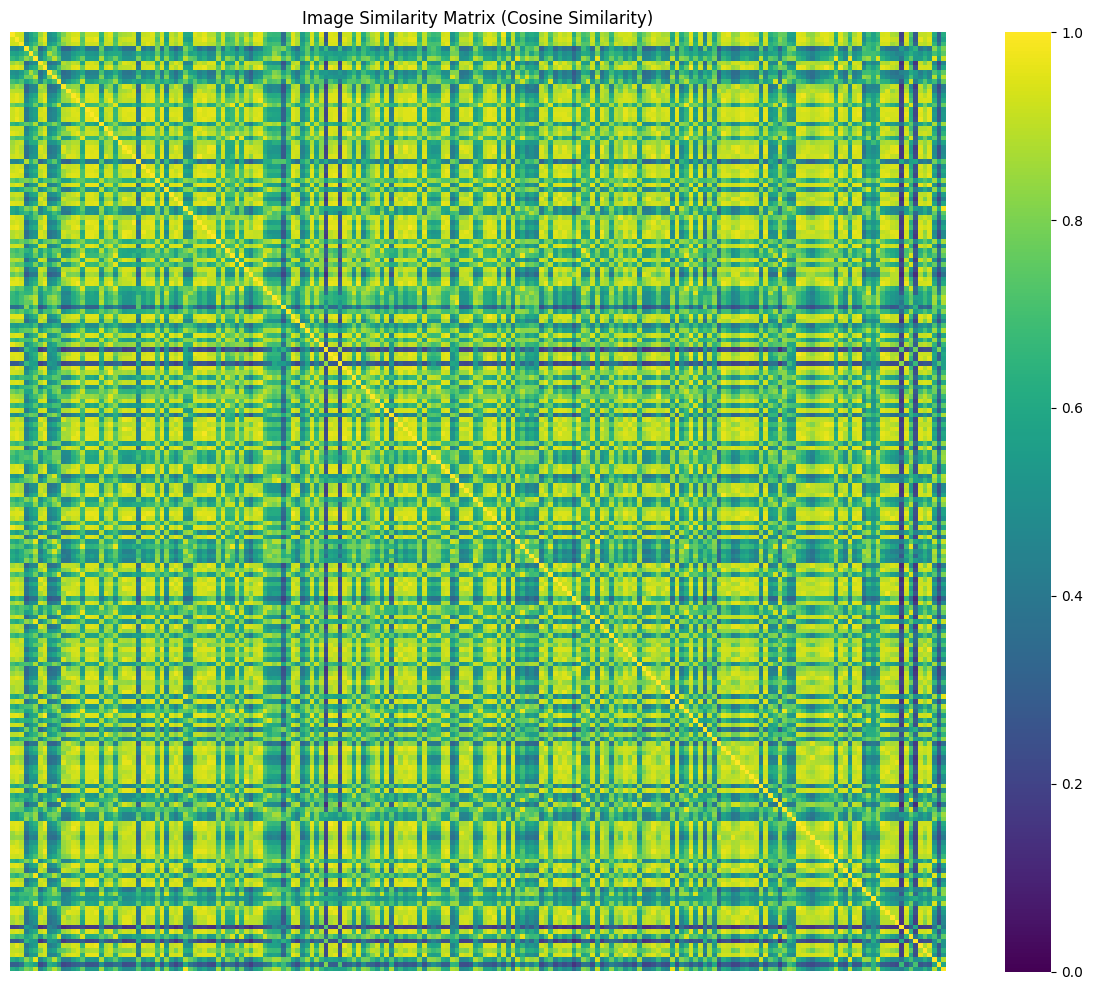


Most similar image pairs:
1. peach_0068.png & peach_0168.png: 0.9918
2. peach_0007.png & peach_0145.png: 0.9889
3. peach_0145.png & peach_0177.png: 0.9880
4. peach_0026.png & peach_0040.png: 0.9880
5. peach_0037.png & peach_0199.png: 0.9859


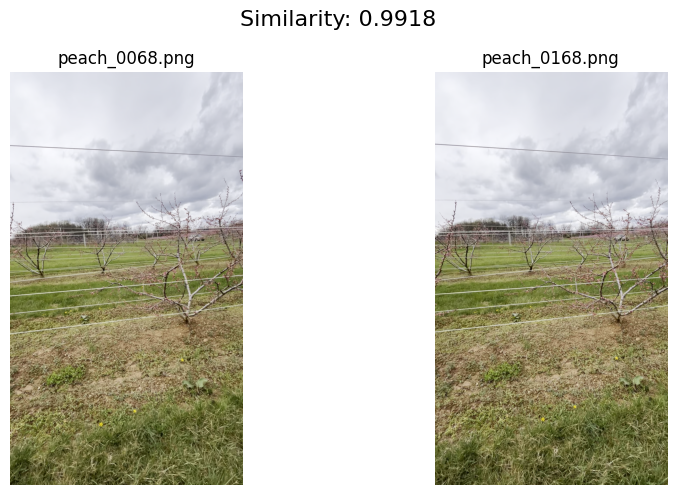

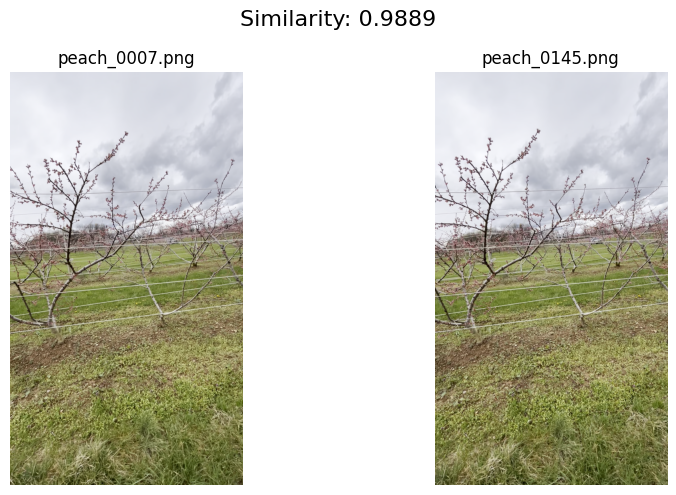

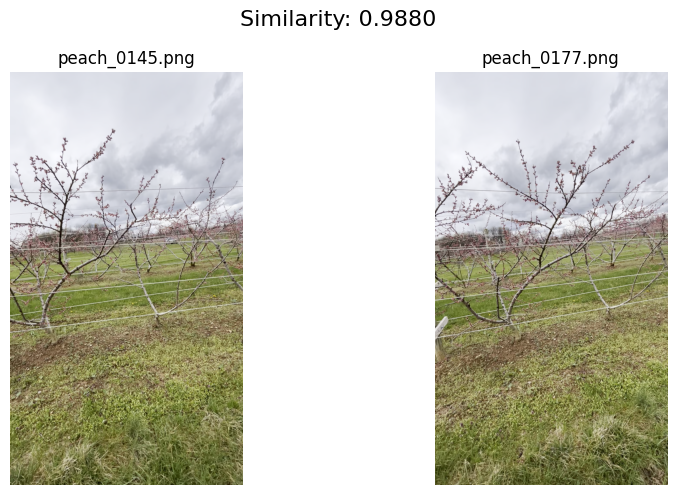

In [39]:
amy_gardens_images_dir = 'data/train/amy_gardens'
    
# Run the test
print("\nRunning test extraction...")
success = test_extraction()
print(f"Test {'succeeded' if success else 'failed'}")

if success:
    # Run the analysis
    analyze_image_folder(amy_gardens_images_dir)